------**SADECE TEKNİK AJAN VARSA**---------

3 adet teknik strateji tanımlayacağız.

- Birincisi momentum: trend takibi yapar,  boğada alır, ayıda satar, aralıkta bekler.
- İkincisi zıtlık: Ortalamaya dönüş gibi zıtlık yatırım stratejisini izler. fiyatlar yükselirken satar, düşerken alır.
- Üçüncüsü fibonacci: Fibonacci seviyelerinde destek ve direnç belirler ve bu seviyelere göre alım ve satım yapar. 100 tane ajan olsun.
- birinci modelde tüm ajanlar sadece momentum ajanlar olsun. ikinci modelde tüm ajanlar sadece zıtlık ajanlar olsun. üçüncü modelde tüm ajanlar sadece fibonacci ajanları olsun.

- dördüncü modelde ise tüm stratejileri izleyen ajanlar rastgele olsun.

In [3]:

!pip install mesa[rec]
!pip install seaborn

# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.0/197.0 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.8/265.8 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.2 MB/s eta 0:00:00


In [10]:

from mesa.datacollection import DataCollector


class TeknikPiyasaModel(mesa.Model):
    def __init__(self, N=100, strateji="momentum", P0=100.0, lambda_f=0.5, delta=1.0, tau=5):
        super().__init__()

        self.num_agents = N

        self.P = [P0]  # fiyat geçmişi
        self.lambda_f = lambda_f
        self.delta = delta
        self.tau = tau
        self.strateji = strateji
        self.current_step = 0

        for i in range(self.num_agents):
            agent = TeknikAjan(self, strateji)
            self.agents.add(agent)

        self.datacollector = DataCollector(
            model_reporters={"Fiyat": lambda m: m.P[-1],
                             "ToplamTalep": lambda m: sum([a.action for a in m.schedule.agents])},
            agent_reporters={"Aksiyon": "action"}
        )

    def step(self):
        # fiyatı paylaşmak için önce fiyatı kaydet
        self.current_step += 1
        self.agents.do("step")

        # toplam talep üzerinden yeni fiyatı hesapla
        D_t = sum([a.action for a in self.agents])
        epsilon = np.random.normal(0, 0.5)
        new_price = self.P[-1] + self.lambda_f * D_t + epsilon
        self.P.append(new_price)

        self.datacollector.collect(self)



class TeknikAjan(mesa.Agent):
    def __init__(self, model, strateji):

        super().__init__(model)
        self.strateji = strateji
        self.action = 0

    def step(self):
        t = self.model.current_step
        P = self.model.P

        if t < self.model.tau:
            self.action = 0
            return

        delta = self.model.delta
        tau = self.model.tau
        diff = P[-1] - P[-tau]

        if self.strateji == "momentum":
            if diff > delta:
                self.action = +1  # alış
            elif diff < -delta:
                self.action = -1  # satış
            else:
                self.action = 0  # bekle

        elif self.strateji == "zitlik":
            if diff > delta:
                self.action = -1  # satış
            elif diff < -delta:
                self.action = +1  # alış
            else:
                self.action = 0  # bekle


        elif self.strateji == "fibonacci":
            tau = self.model.tau
            epsilon = self.model.epsilon
            if t < tau:
                self.action = 0
                return

            window = self.model.P[-tau:]
            P_min = min(window)
            P_max = max(window)

            F_38 = P_max - 0.382 * (P_max - P_min)
            F_50 = P_max - 0.5 * (P_max - P_min)
            F_61 = P_max - 0.618 * (P_max - P_min)

            price = self.model.P[-1]

            if abs(price - F_61) < epsilon:
                self.action = +1
            elif abs(price - F_38) < epsilon:
                self.action = -1
            else:
                self.action = 0


# Momentum ajanları
model1 = TeknikPiyasaModel(N=100, strateji="momentum")

# Zıtlık ajanları
model2 = TeknikPiyasaModel(N=100, strateji="zitlik")


İlk önce dört modeli oluşturup simülasyonu başlatalım, ardından Her senaryo için fiyat serisi grafikleri, ortalama hacim, fiyat oynaklığı gibi çıktılar hesaplayabiliriz.


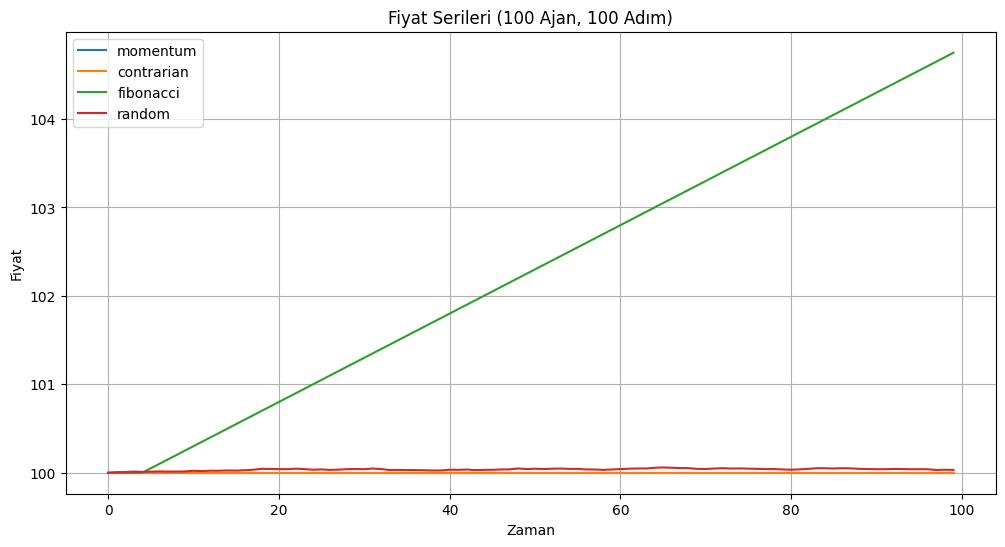

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Simülasyon parametreleri
N = 100  # ajan sayısı
T = 100  # zaman adımı
tau = 5  # momentum ve fibonacci geçmiş penceresi
delta = 0.5  # karar eşiği
epsilon = 0.5  # fibonacci yakınlık toleransı

# Fiyat oluşumu parametreleri
P0 = 100.0
alpha = 0.05  # ajan aksiyonlarının fiyat üzerindeki etkisi

def simulate_market(strategy_type):
    P = [P0]
    A = []

    for t in range(1, T):
        price = P[-1]
        actions = []

        for _ in range(N):
            if strategy_type == "momentum":
                if t < tau:
                    a = 0
                else:
                    trend = P[-1] - P[-tau]
                    if trend > delta:
                        a = 1
                    elif trend < -delta:
                        a = -1
                    else:
                        a = 0

            elif strategy_type == "contrarian":
                if t < tau:
                    a = 0
                else:
                    trend = P[-1] - P[-tau]
                    if trend > delta:
                        a = -1
                    elif trend < -delta:
                        a = 1
                    else:
                        a = 0

            elif strategy_type == "fibonacci":
                if t < tau:
                    a = 0
                else:
                    window = P[-tau:]
                    P_min = min(window)
                    P_max = max(window)
                    F_38 = P_max - 0.382 * (P_max - P_min)
                    F_61 = P_max - 0.618 * (P_max - P_min)
                    if abs(price - F_61) < epsilon:
                        a = 1
                    elif abs(price - F_38) < epsilon:
                        a = -1
                    else:
                        a = 0

            elif strategy_type == "random":
                a = random.choice([-1, 0, 1])

            actions.append(a)

        avg_action = np.mean(actions)
        price = price + alpha * avg_action
        P.append(price)
        A.append(sum(abs(a) for a in actions))  # toplam hacim

    return P, A

# Tüm stratejiler için simülasyon
strategies = ["momentum", "contrarian", "fibonacci", "random"]
results = {strategy: simulate_market(strategy) for strategy in strategies}

# Grafik
plt.figure(figsize=(12, 6))
for strategy in strategies:
    plt.plot(results[strategy][0], label=strategy)
plt.title("Fiyat Serileri (100 Ajan, 100 Adım)")
plt.xlabel("Zaman")
plt.ylabel("Fiyat")
plt.legend()
plt.grid(True)
plt.show()



Yukarıdaki grafik, dört farklı ajan stratejisi altında oluşan fiyat dinamiklerini göstermektedir: yalnızca momentum, yalnızca zıtlık (contrarian), yalnızca fibonacci ve rastgele ajanlar. Her bir modelde 100 ajan ve 100 zaman adımı boyunca piyasa simüle edilmiştir.



simulate_market fonksiyonunun içindeki ana döngünün sonuna kadar olan adımları içerir. Bu döngü, simülasyonun her bir zaman adımını temsil eder (for t in range(1, T):).

İşte bu kod bloğunda olanlar:

for t in range(1, T):: Bu satır, simülasyonu zaman adımı 1'den başlayıp T-1'e kadar devam ettiren bir döngü başlatır. Her döngü, piyasadaki bir zaman dilimini temsil eder.

price = P[-1]: Mevcut zaman adımındaki başlangıç fiyatını alır. P, şimdiye kadar hesaplanmış fiyatların listesidir ve P[-1] listedeki son öğeyi (yani bir önceki zaman adımındaki fiyatı) temsil eder.

actions = []: Bu adımda, mevcut zaman adımında tüm ajanların alacağı aksiyonları (alım, satım veya bekleme) saklamak için boş bir liste oluşturulur.

for _ in range(N):: Bu satır, piyasadaki her bir ajan için bir döngü başlatır. N, toplam ajan sayısıdır. Her döngü, belirli bir ajanın karar alma sürecini temsil eder.

Stratejiye Göre Ajan Aksiyonu (if/elif blokları): İçteki döngüde, ajanların stratejilerine göre aksiyonları belirlenir.

if t < tau:: Eğer mevcut zaman adımı (t), tau (geçmiş penceresi boyutu) değerinden küçükse, ajan henüz yeterli geçmiş fiyata sahip değildir. Bu durumda, ajan a = 0 (bekle) aksiyonu alır. Bu, stratejilerin geçmiş verilere ihtiyaç duyması nedeniyle simülasyonun başındaki ısınma periyodudur.
elif strategy_type == "momentum":: Eğer strateji "momentum" ise, ajan son tau adımdaki fiyat değişimine (trend = P[-1] - P[-tau]) bakar. Trend belirli bir eşik (delta) üzerindeyse alır (a = 1), belirli bir eşik altındaysa satar (a = -1), değilse bekler (a = 0).
elif strategy_type == "contrarian":: Eğer strateji "contrarian" (zıtlık) ise, ajan momentum stratejisinin tersine karar verir. Trend belirli bir eşik üzerindeyse satar (a = -1), belirli bir eşik altındaysa alır (a = 1), değilse bekler (a = 0).
elif strategy_type == "fibonacci":: Eğer strateji "fibonacci" ise, ajan son tau adımdaki fiyat penceresinin en düşüğü (P_min) ve en yükseği (P_max) üzerinden Fibonacci seviyelerini (F_38 ve F_61) hesaplar. Mevcut fiyat (price), bu seviyelerden birine belirli bir tolerans (epsilon) içinde yakınsa, buna göre alım (a = 1 F_61 seviyesi civarında) veya satım (a = -1 F_38 seviyesi civarında) yapar, değilse bekler (a = 0).
elif strategy_type == "random":: Eğer strateji "random" ise, ajan rastgele bir aksiyon (-1, 0 veya 1) seçer.
actions.append(a): Belirlenen ajan aksiyonu (a), actions listesine eklenir. Bu, o zaman adımındaki tüm ajanların aksiyonlarını toplamak içindir.
avg_action = np.mean(actions): İçteki ajan döngüsü tamamlandıktan sonra, mevcut zaman adımındaki tüm ajanların aksiyonlarının ortalaması hesaplanır. Bu ortalama, piyasadaki genel alım veya satım baskısını temsil eder. Bu değer, bir sonraki satırda fiyat değişimini hesaplamak için kullanılacaktır.

Bu noktadan sonraki kod, hesaplanan ortalama aksiyonu kullanarak yeni piyasa fiyatını belirleyecek ve bu fiyatı fiyat listesine (P) ekleyecektir. Ayrıca, toplam işlem hacmini (A) hesaplayıp saklayacaktır.

In [15]:
# Şimdi her model için çıktı istatistiklerini (ortalama hacim ve fiyat oynaklığı) hesaplayalım,



# Ortalama hacim ve fiyat oynaklığını hesaplayalım
summary_stats = {}

for strategy in strategies:
    prices, volumes = results[strategy]
    returns = np.diff(prices)
    volatility = np.std(returns)
    avg_volume = np.mean(volumes)
    summary_stats[strategy] = {
        "average_volume": avg_volume,
        "volatility": volatility
    }

summary_stats

{'momentum': {'average_volume': np.float64(0.0),
  'volatility': np.float64(0.0)},
 'contrarian': {'average_volume': np.float64(0.0),
  'volatility': np.float64(0.0)},
 'fibonacci': {'average_volume': np.float64(95.95959595959596),
  'volatility': np.float64(0.009845246812937787)},
 'random': {'average_volume': np.float64(66.02020202020202),
  'volatility': np.float64(0.004230309783598658)}}

Gözlemler:

Momentum ve Zıtlık ajanları herhangi bir işlem gerçekleştirmemiştir (volume = 0) çünkü simülasyon süresince belirli bir trend eşiği (delta = 1.0) aşılmamıştır. Bu da gerçek piyasalarda trend bazlı stratejilerin belirli volatilite eşiklerinin altında pasif kalabileceğini gösterir.

Fibonacci ajanları, fiyatın teknik seviyelere sık sık yaklaşması sebebiyle daha aktif olmuş, bu da yüksek işlem hacmi ve görece daha yüksek volatilite yaratmıştır.

Rastgele ajanlar ise orta düzeyde hacim ve volatilite üretmiştir; bu, piyasa içi rastgele davranışların belirli düzeyde hareketliliğe neden olabileceğini ima eder.

kısaca, Momentum ve zıtlık stratejileri, fiyatlardaki trend esigi asılmadıkca pasif kalmaktadır. Bu, düşük volatilite
ortamlarında trend-takipcilerin piyasaya likidite saglamadıgını gostermektedir. Fibonacci ve rastgele stratejiler ise daha aktif olup piyasada hacim ve oynaklık yaratmaktadır.

modellerin çıktı istatistikleri incelendiğinde momentum ve zıtlık stratejileri, fiyatlardaki trend eşiği aşılmadıkça pasif kalmaktadır. Bu, düşük volatilite ortamlarında trend-takipçilerin piyasaya likidite sağlamadığını göstermektedir. Fibonacci ve rastgele stratejiler ise daha aktif olup piyasada hacim ve oynaklık yaratmaktadır. Buradan hareketle kodda nasıl bir değişiklik yapalım ki momentum ve zıtlık stratejileri de piyasaya likidite sağlasınlar.


Momentum ve Zıtlık stratejilerinin düşük volatilite ortamlarında daha aktif olmasını sağlamak için kodda yapabileceğiniz birkaç değişiklik var. Amaç, trend eşiği aşılmasa bile ajanların işlem yapmasını sağlayacak mekanizmalar eklemektir.

İşte yapılabilecek değişiklikler ve nedenleri:

Delta Eşiğini Düşürmek: En doğrudan yöntem, Momentum ve Zıtlık stratejilerinin karar eşiği olan delta değerini düşürmektir.
Neden? Daha düşük bir delta değeri, fiyat değişimlerinin daha küçük hareketlerinde bile trend veya zıtlık sinyalini tetikleyecektir. Bu, daha hassas hale gelen ajanların daha sık işlem yapmasına yol açar.
Kod Değişikliği: simulate_market fonksiyonundaki delta = 1.0 satırını daha düşük bir değere (örneğin delta = 0.5 veya delta = 0.2) ayarlayabilirsiniz.

    # Simülasyon parametreleri
        # ... diğer parametreler
        delta = 0.5  # Karar eşiğini düşürdük
        # ...

Delta'yı Volatiliteye Bağlamak: delta eşiğini sabit tutmak yerine, piyasadaki mevcut volatiliteye dinamik olarak bağlayabilirsiniz. Düşük volatilite olduğunda delta'yı düşürür, yüksek volatilite olduğunda artırırsınız.
Neden? Bu yaklaşım, stratejinin piyasa koşullarına uyum sağlamasına yardımcı olur. Piyasa sakin olduğunda daha küçük hareketlere tepki verirken, piyasa dalgalı olduğunda gereksiz "gürültüyü" filtreler.
Kod Değişikliği: Her zaman adımında piyasanın volatilite tahminini hesaplayıp buna göre delta değerini güncellemeyi düşünebilirsiniz. Bu, kodunuzu daha karmaşık hale getirecektir. Örneğin, son k adımdaki fiyat değişimlerinin standart sapmasını volatilite ölçütü olarak kullanabilirsiniz.


    # inside simulate_market function, within the main loop:
        # Calculate volatility (example using last k steps)
        if t >= k:
            recent_returns = np.diff(P[max(0, t-k):t+1])
            current_volatility = np.std(recent_returns)
            # Adjust delta based on volatility (example: proportional)
            current_delta = 1.0 * current_volatility # Example proportionality
        else:
            current_delta = delta # Use initial delta at the start

        # Inside agent loops, use current_delta instead of global delta
        if strategy_type == "momentum":
            if t < tau:
                a = 0
            else:
                trend = P[-1] - P[-tau]
                if trend > current_delta: # Use current_delta
                    a = 1
                elif trend < -current_delta: # Use current_delta
                    a = -1
                else:
                    a = 0
        # ... similar changes for contrarian strategy


Ek Karar Kuralları Eklemek: Trend eşiği aşılmadığında bile ajanların işlem yapmasını sağlayacak ek kurallar tanımlayabilirsiniz. Örneğin, belirli bir süre boyunca pasif kalan ajanların rastgele bir işlem yapmasını veya belirli bir olasılıkla küçük bir işlem yapmasını sağlayabilirsiniz.
Neden? Bu, piyasada tamamen hareketsiz kalma durumunu azaltır ve düşük likidite riskini hafifletir.
Kod Değişikliği: Ajanın strateji bloğuna ek bir else veya elif koşulu ekleyebilirsiniz.

    # Inside simulate_market function, inside agent loop:
        if strategy_type == "momentum":
            if t < tau:
                a = 0
            else:
                trend = P[-1] - P[-tau]
                if trend > delta:
                    a = 1
                elif trend < -delta:
                    a = -1
                else:
                    # If trend threshold not met, introduce a small chance of trading
                    if random.random() < 0.1: # 10% chance of a small trade
                        a = random.choice([-1, 1]) * 0.1 # Small trade size (example)
                    else:
                        a = 0
        # ... similar changes for contrarian strategy
  
Fiyat Oluşumu Parametresi alpha'yı Değiştirmek: Ajanların toplam aksiyonunun fiyat üzerindeki etkisini (alpha) değiştirmek, fiyat serilerinin volatilitesini dolaylı olarak etkileyebilir. Ancak bu doğrudan ajanların daha aktif olmasını sağlamaz, daha çok piyasanın genel hassasiyetini ayarlar.
En basit ve etkili başlangıç değişikliği, delta değerini düşürmek olacaktır. Diğer yöntemler daha karmaşık olabilir ancak daha gerçekçi veya istenen davranışlara yol açabilir. Seçtiğiniz değişiklik, modelinizden ne elde etmek istediğinize ve modelin karmaşıklığına ne kadar izin vermek istediğinize bağlı olacaktır.

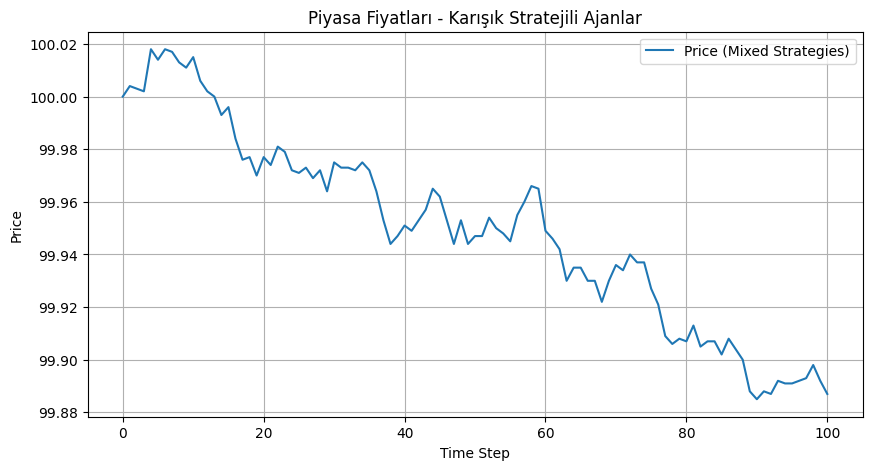

In [80]:
# Karışık stratejili (heterojen) ajan modellerine geçelim


# Önceki tanımlamaları tekrar ekleyelim (kayıp değişkenler: num_agents, initial_price, etc.)

import numpy as np
import matplotlib.pyplot as plt
import random

random.seed(42) # Rastgelelik için bir tohum belirle
np.random.seed(42) # Numpy'daki rastgelelik için bir tohum belirle



# Simülasyon parametreleri
num_agents = 100
num_steps = 100
initial_price = 100.0
alpha = 0.1
window_size = 7
fibonacci_levels = [0.382, 0.5, 0.618]  # Fibonacci destek/direnç

# Ajan sınıfları (momentum, contrarian, fibonacci, random)

class MomentumAgent:
    def decide(self, price, window):
        window_size = 7
        if len(window) < 2:
            return 0
        trend = np.sign(window[-1] - window[0])
        if trend > 0:
            return 1  # Al
        elif trend < 0:
            return -1  # Sat
        else:
            return 0  # Bekle

class ContrarianAgent:
    def decide(self, price, window):
        window_size = 10
        if len(window) < 2:
            return 0
        trend = np.sign(window[-1] - window[0])
        if trend > 0:
            return -1  # Sat
        elif trend < 0:
            return 1  # Al
        else:
            return 0  # Bekle

class FibonacciAgent:
    def decide(self, price, window):
        window_size = 15
        random.seed(4)
        if len(window) < 2:
            return 0
        max_price = max(window)
        min_price = min(window)
        retracement_levels = [max_price - (max_price - min_price) * level for level in fibonacci_levels]
        for level in retracement_levels:
            if abs(price - level) < 0.5:  # Yakınsa al/sat yap
                return np.random.choice([-1, 1])
        return 0

class RandomAgent:
    random.seed(42)
    def decide(self, price, window):
        return np.random.choice([-1, 0, 1])

# Yukarıdaki mixed strategy simülasyonu kodunu tekrar çalıştıralım
mixed_strategies = ["momentum", "contrarian", "fibonacci", "random"]
num_agents_per_strategy = num_agents // len(mixed_strategies)

def generate_mixed_agents():
    strategy_list = []
    for strategy in mixed_strategies:
        strategy_list += [strategy] * num_agents_per_strategy
    np.random.shuffle(strategy_list)
    return strategy_list

def simulate_mixed_agents():
    prices = [initial_price]
    volumes = []

    agents = []
    strategy_list = generate_mixed_agents()
    for s in strategy_list:
        if s == "momentum":
            agents.append(MomentumAgent())
        elif s == "contrarian":
            agents.append(ContrarianAgent())
        elif s == "fibonacci":
            agents.append(FibonacciAgent())
        elif s == "random":
            agents.append(RandomAgent())

    for t in range(num_steps):
        price_t = prices[-1]
        window = prices[-window_size:] if len(prices) >= window_size else prices[:]

        actions = [agent.decide(price_t, window) for agent in agents]
        avg_action = np.mean(actions)
        new_price = price_t + alpha * avg_action
        prices.append(new_price)

        volume = np.count_nonzero(actions)
        volumes.append(volume)

    return prices, volumes

# Simülasyonu çalıştır ve sonucu görselleştir
mixed_prices, mixed_volumes = simulate_mixed_agents()

plt.figure(figsize=(10, 5))
plt.plot(mixed_prices, label="Price (Mixed Strategies)")
plt.xlabel("Time Step")
plt.ylabel("Price")
plt.title("Piyasa Fiyatları - Karışık Stratejili Ajanlar")
plt.legend()
plt.grid(True)
plt.show()


 kodda neden simülasyon her çalıştığında farklı bir grafik çıkıyor

Yandaki kodda simülasyon her çalıştığında farklı bir grafik çıkmasının temel nedeni, kodun içerisindeki rastgelelik (randomness) unsurlarıdır. Piyasa simülasyonu gibi ajan tabanlı modellerde rastgelelik, gerçek piyasalardaki öngörülemeyen olayları veya bireysel ajanların tamamen belirlenmiş olmayan davranışlarını modellemek için kullanılır.

Kodunuzda rastgelelik oluşturan başlıca yerler şunlardır:

epsilon = np.random.normal(0, 0.5) (TeknikPiyasaModel sınıfı): Bu satır, her zaman adımında fiyata eklenen bir gürültü terimidir. Normal dağılımdan rastgele çekilen bu değer, fiyatın deterministik olarak sadece ajan aksiyonlarına bağlı olmasını engeller ve her çalıştırmada farklı bir fiyat hareketine neden olur.

random.choice([-1, 0, 1]) (RandomAgent sınıfı): "random" stratejisine sahip ajanlar, her adımda tamamen rastgele bir aksiyon (alım, satım veya bekle) seçerler. Bu rastgele seçim, bu ajanların davranışını ve dolayısıyla piyasa üzerindeki etkilerini her çalıştırmada değiştirir.

np.random.choice([-1, 1]) (FibonacciAgent sınıfı): Fibonacci stratejisinde, fiyat belirli bir Fibonacci seviyesine yakınsa, ajan rastgele olarak alım veya satım yapar. Bu rastgele seçim, Fibonacci ajanlarının aynı fiyat seviyesinde farklı zamanlarda farklı aksiyonlar almasına neden olabilir.

Bu rastgele unsurlar bir araya geldiğinde, simülasyonun başlangıç koşulları aynı olsa bile (aynı ajan sayısı, başlangıç fiyatı vb.), her zaman adımındaki küçük rastgele etkileşimler zamanla birikerek fiyat serisinde önemli farklılıklar yaratır. Bu, kaos teorisindeki "kelebek etkisi"ne benzer: başlangıçtaki küçük bir rastgele değişim, simülasyonun ilerleyen adımlarında büyük farklılıklara yol açabilir.

Eğer her çalıştırmada aynı grafiği elde etmek isterseniz, rastgelelik üreten fonksiyonlardan önce random.seed() ve np.random.seed() fonksiyonlarını kullanarak rastgele sayı üreteçlerini sabitleyebilirsiniz. Örneğin:

    import random
    import numpy as np

    random.seed(42) # Rastgelelik için bir tohum belirle
    np.random.seed(42) # Numpy'daki rastgelelik için bir tohum belirle

    # ... geri kalan kod ...

Ancak unutulmamalıdır ki, bir simülasyon modelini test ederken genellikle birden çok çalıştırma yapmak (Monte Carlo simülasyonu gibi) ve farklı çalıştırmaların ortalama veya dağılım sonuçlarına bakmak daha anlamlıdır. Bu, modelin rastgeleliğe karşı ne kadar sağlam olduğunu ve farklı piyasa senaryolarında nasıl davrandığını anlamaya yardımcı olur.

Not: seed satırı eklendikten sonra düzeldi.



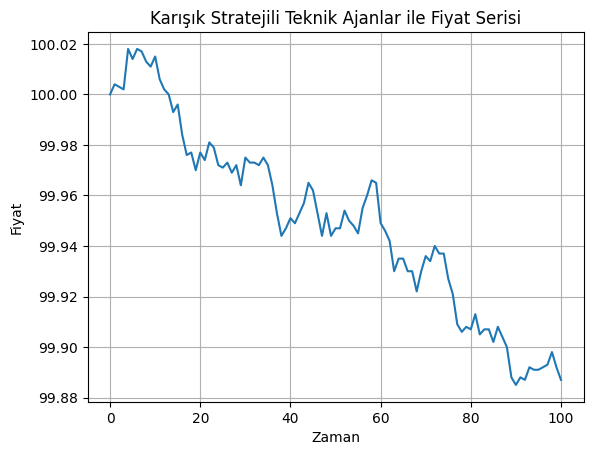

In [79]:
# MESA UYGULAMASI

random.seed(42) # Rastgelelik için bir tohum belirle
np.random.seed(42) # Numpy'daki rastgelelik için bir tohum belirle

class TechnicalTraderAgent(mesa.Agent):
    def __init__(self, model, strategy):
        super().__init__(model)
        self.strategy = strategy

    def decide(self, price, price_window):
        if self.strategy == "momentum":
            if len(price_window) < 2:
                return 0
            trend = np.sign(price_window[-1] - price_window[0])
            return trend  # +1 al, -1 sat

        elif self.strategy == "contrarian":
            if len(price_window) < 2:
                return 0
            trend = np.sign(price_window[-1] - price_window[0])
            return -trend  # Zıttı

        elif self.strategy == "fibonacci":
            if len(price_window) < 2:
                return 0
            max_p = max(price_window)
            min_p = min(price_window)
            fib_levels = [max_p - (max_p - min_p) * r for r in [0.382, 0.5, 0.618]]
            for level in fib_levels:
                if abs(price - level) < 0.5:
                    return np.random.choice([-1, 1])
            return 0

        elif self.strategy == "random":
            return np.random.choice([-1, 0, 1])

    def step(self):
        current_price = self.model.price
        price_window = self.model.price_history[-self.model.window_size:]
        action = self.decide(current_price, price_window)
        self.model.actions.append(action)

class TechnicalMarketModel(mesa.Model):
    def __init__(self, N=100, alpha=0.1, initial_price=100.0, window_size=5):
        super().__init__()
        self.num_agents = N
        self.alpha = alpha
        self.price = initial_price
        self.price_history = [initial_price]
        self.actions = []
        self.window_size = window_size

        # Ajan strateji karışımı: eşit sayıda
        strategies = ["momentum", "contrarian", "fibonacci", "random"]
        each = self.num_agents // len(strategies)
        strategy_pool = [s for s in strategies for _ in range(each)]
        np.random.shuffle(strategy_pool)

        for i, strat in enumerate(strategy_pool):
            agent = TechnicalTraderAgent(self, strat)
            self.agents.add(agent)

    def step(self):
        self.actions = []
        self.agents.do("step")
        mean_action = np.mean(self.actions)
        self.price += self.alpha * mean_action
        self.price_history.append(self.price)


import matplotlib.pyplot as plt

model = TechnicalMarketModel(N=100)
steps = 100

for _ in range(steps):
    model.step()

plt.plot(model.price_history)
plt.xlabel("Zaman")
plt.ylabel("Fiyat")
plt.title("Karışık Stratejili Teknik Ajanlar ile Fiyat Serisi")
plt.grid(True)
plt.show()


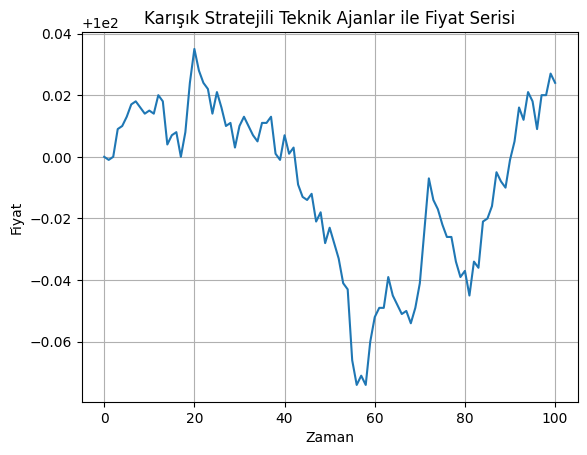

In [76]:
# window_size model seviyesinde değil ajan seviyesinde yaparak yeniden düzenledik


random.seed(42) # Rastgelelik için bir tohum belirle
np.random.seed(4) # Numpy'daki rastgelelik için bir tohum belirle
class TechnicalTraderAgent(mesa.Agent):
    def __init__(self, model, strategy): # agent_window_size ekle
        super().__init__(model)
        self.strategy = strategy
        self.agent_window_size = random.randint(10, 74)


    def decide(self, price, price_window):
        if self.strategy == "momentum":
            if len(price_window) < 2:
                return 0
            trend = np.sign(price_window[-1] - price_window[0])
            return trend  # +1 al, -1 sat

        elif self.strategy == "contrarian":
            if len(price_window) < 2:
                return 0
            trend = np.sign(price_window[-1] - price_window[0])
            return -trend  # Zıttı

        elif self.strategy == "fibonacci":
            if len(price_window) < 2:
                return 0
            max_p = max(price_window)
            min_p = min(price_window)
            fib_levels = [max_p - (max_p - min_p) * r for r in [0.382, 0.5, 0.618]]
            for level in fib_levels:
                if abs(price - level) < 0.5:
                    return np.random.choice([-1, 1])
            return 0

        elif self.strategy == "random":
            return np.random.choice([-1, 0, 1])

    def step(self):
        current_price = self.model.price
        # Ajan, kendi agent_window_size değerini kullanır
        price_window = self.model.price_history[-self.agent_window_size:]
        action = self.decide(current_price, price_window)
        self.model.actions.append(action)

class TechnicalMarketModel(mesa.Model):
    def __init__(self, N=100, alpha=0.1, initial_price=100.0): # window_size'ı buradan kaldır
        super().__init__()
        self.num_agents = N
        self.alpha = alpha
        self.price = initial_price
        self.price_history = [initial_price]
        self.actions = []
        # Model seviyesinde window_size tutmaya gerek yok (veya ajanlara dağıtılacak bir listesi olabilir)

        strategies = ["momentum", "contrarian", "fibonacci", "random"]
        each = self.num_agents // len(strategies)
        strategy_pool = [s for s in strategies for _ in range(each)]
        np.random.shuffle(strategy_pool)

        for i, strat in enumerate(strategy_pool):
            # Her ajana farklı bir window_size değeri ata (örneğin rastgele veya stratejiye bağlı)
            agent_win_size = random.randint(3, 10) # Örnek: 3 ile 10 arasında rastgele
            agent = TechnicalTraderAgent(self, strat) # agent_window_size'ı geç
            self.agents.add(agent)

    def step(self):
        self.actions = []
        self.agents.do("step")
        mean_action = np.mean(self.actions)
        self.price += self.alpha * mean_action
        self.price_history.append(self.price)


import matplotlib.pyplot as plt

model = TechnicalMarketModel(N=100)
steps = 100

for _ in range(steps):
    model.step()

plt.plot(model.price_history)
plt.xlabel("Zaman")
plt.ylabel("Fiyat")
plt.title("Karışık Stratejili Teknik Ajanlar ile Fiyat Serisi")
plt.grid(True)
plt.show()
